# Exploratory Data Analysis — NC Traffic Stop Arrests
**SDS 357 — Spring 2026**

Analysis of 4M+ traffic stops across six North Carolina cities (2000–2015) from the Stanford Open Policing Project (SOPP), supplemented with FBI Uniform Crime Report data.

In [1]:
import os
os.makedirs('eda', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)

PALETTE_RACE = {"black": "#4C72B0", "white": "#DD8452",
                "hispanic": "#55A868", "asian/pacific islander": "#C44E52"}
RACE_ORDER = ["black", "white", "hispanic", "asian/pacific islander"]
CITY_ORDER = ["Charlotte", "Raleigh", "Greensboro", "Fayetteville", "Winston-Salem", "Durham"]
SEED = 42

## Data Loading & Preparation

In [2]:
df = pd.read_parquet("data/nc_traffic_stops_cleaned.parquet")
df = df[df["subject_race"].isin(RACE_ORDER)].copy()
df = df[~df["outcome_missing"]].copy()
df = df[df["hour"].notna() & df["subject_age"].notna()].copy()
df["hour"] = df["hour"].astype(int)
df["subject_age"] = df["subject_age"].astype(float)
df = df.reset_index(drop=True)

# Merge FBI crime rates (violent + property per 1k) by city-year
fbi = pd.read_csv("data/nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
df = df.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
              left_on=["city", "year"], right_on=["City", "Year"], how="left")
df.drop(columns=["City", "Year"], inplace=True)
# Fill years outside FBI coverage with city-level averages
city_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean()
for col in ["violent_crime_rate", "property_crime_rate"]:
    df[col] = df.apply(lambda r: city_avg.loc[r["city"], col]
                        if pd.isna(r[col]) else r[col], axis=1)

print(f"Dataset: {len(df):,} stops across {df['city'].nunique()} cities ({int(df['year'].min())}–{int(df['year'].max())})")
print(f"Arrest rate: {df['arrested'].mean()*100:.2f}%")
print(f"FBI crime rates merged: violent_crime_rate and property_crime_rate columns added")
df.head()

Dataset: 3,961,022 stops across 6 cities (2000–2015)
Arrest rate: 2.81%
FBI crime rates merged: violent_crime_rate and property_crime_rate columns added


,date,time,city,subject_race,subject_sex,subject_age,reason_for_stop,outcome,search_conducted,arrested,year,month,day_of_week,hour,outcome_missing,violent_crime_rate,property_crime_rate
0,2000-01-01,17:20:00,Charlotte,black,female,38.0,Safe Movement Violation,warning,False,0,2000,1,Saturday,17,False,7.461077,48.541918
1,2000-01-02,11:40:00,Charlotte,hispanic,male,33.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,11,False,7.461077,48.541918
2,2000-01-02,02:41:00,Charlotte,white,male,23.0,Vehicle Equipment Violation,citation,False,0,2000,1,Sunday,2,False,7.461077,48.541918
3,2000-01-23,03:35:00,Charlotte,white,female,23.0,Vehicle Regulatory Violation,citation,False,0,2000,1,Sunday,3,False,7.461077,48.541918
4,2000-01-02,16:45:00,Charlotte,white,female,23.0,Safe Movement Violation,warning,False,0,2000,1,Sunday,16,False,7.461077,48.541918


## Exploratory Data Analysis

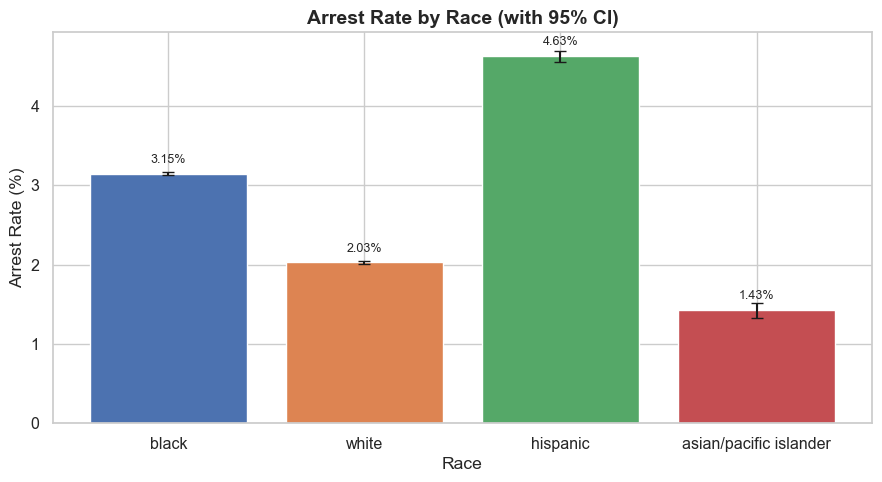

In [3]:
# Figure 1: Arrest Rate by Race (with 95% CI)
def arrest_rate_ci(group, z=1.96):
    n = len(group); p = group.mean()
    se = np.sqrt(p*(1-p)/n) if n > 0 else 0
    return pd.Series({"rate": p*100, "ci": z*se*100, "n": n})

arr_race = df.groupby("subject_race")["arrested"].apply(arrest_rate_ci).unstack()
arr_race = arr_race.reindex([r for r in RACE_ORDER if r in arr_race.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(arr_race.index, arr_race["rate"], yerr=arr_race["ci"], capsize=4,
              color=[PALETTE_RACE[r] for r in arr_race.index], edgecolor="white")
ax.set_title("Arrest Rate by Race (with 95% CI)", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("Arrest Rate (%)")
for b, rate in zip(bars, arr_race["rate"]):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("eda/01_arrest_rate_by_race.png", dpi=150, bbox_inches="tight")
plt.show()

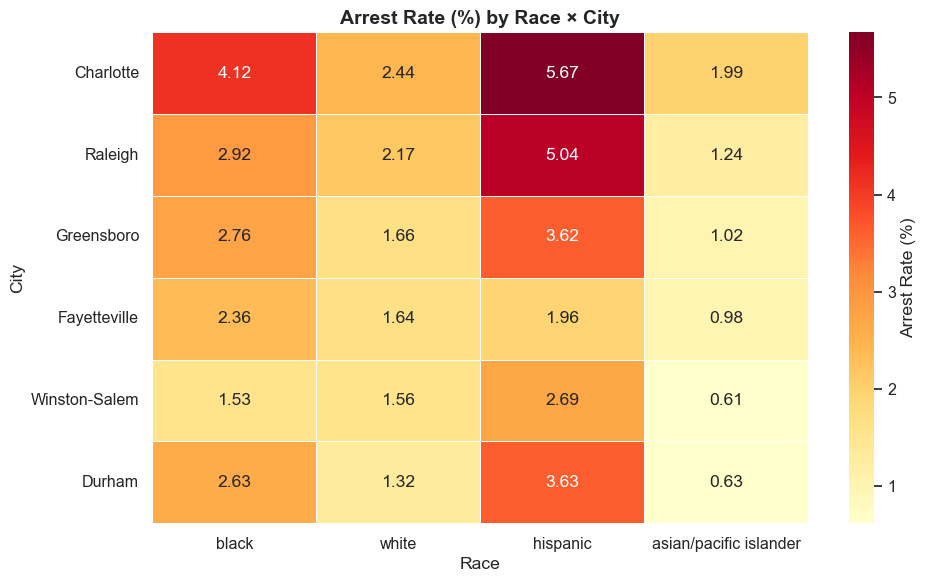

In [4]:
# Figure 2: Arrest Rate (%) by Race x City — Heatmap
arr_rc = df.groupby(["city", "subject_race"])["arrested"].mean().unstack() * 100
arr_rc = arr_rc.reindex(index=[c for c in CITY_ORDER if c in arr_rc.index],
                        columns=[r for r in RACE_ORDER if r in arr_rc.columns])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(arr_rc, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Arrest Rate (%)"})
ax.set_title("Arrest Rate (%) by Race × City", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("City")
plt.tight_layout()
plt.savefig("eda/02_arrest_rate_race_city_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

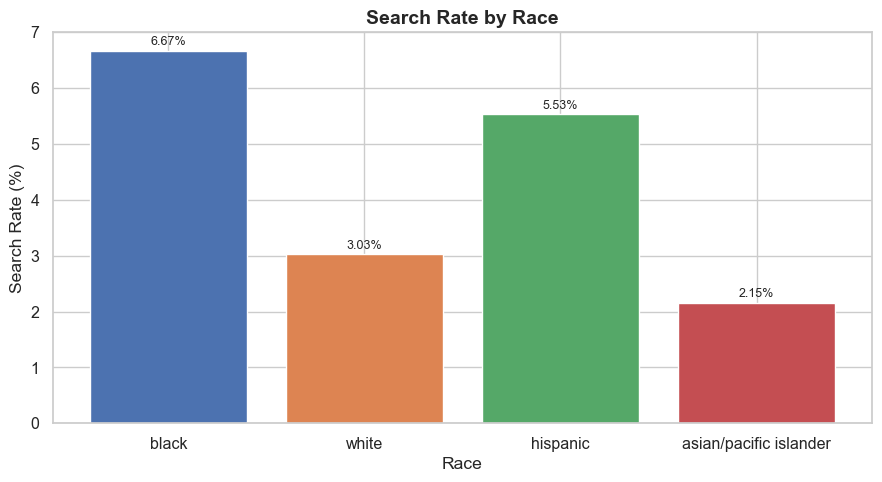

In [5]:
# Figure 3: Search Rate by Race
search_race = df.groupby("subject_race")["search_conducted"].mean() * 100
search_race = search_race.reindex([r for r in RACE_ORDER if r in search_race.index])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(search_race.index, search_race.values,
              color=[PALETTE_RACE[r] for r in search_race.index], edgecolor="white")
ax.set_title("Search Rate by Race", fontsize=14, fontweight="bold")
ax.set_xlabel("Race"); ax.set_ylabel("Search Rate (%)")
for b, rate in zip(bars, search_race.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f"{rate:.2f}%",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("eda/03_search_rate_by_race.png", dpi=150, bbox_inches="tight")
plt.show()

## FBI Crime Data — Contextualizing Stop and Arrest Rates

In [6]:
# Load FBI Uniform Crime Report data for NC cities
fbi = pd.read_csv("data/nc_fbi_crime_data_clean.csv", index_col=0)
fbi["violent_crime_rate"] = fbi["Violent crime"] / fbi["Population"] * 1000
fbi["property_crime_rate"] = fbi["Property crime"] / fbi["Population"] * 1000
fbi = fbi.sort_values(["City", "Year"])
print(f"FBI data: {len(fbi)} city-year records, years {fbi['Year'].min()}–{fbi['Year'].max()}")
fbi[["City", "Year", "Population", "violent_crime_rate", "property_crime_rate"]].head(10)

FBI data: 52 city-year records, years 2006–2015


,City,Year,Population,violent_crime_rate,property_crime_rate
15,Charlotte,2006,699398,10.769262,69.897254
0,Charlotte,2007,733291,9.863751,69.929946
40,Charlotte,2008,758769,9.317724,61.855453
46,Charlotte,2009,777708,7.232792,49.546874
21,Charlotte,2010,797733,6.131124,43.499517
27,Charlotte,2011,789478,6.063500,40.543245
9,Charlotte,2012,808504,6.478632,40.305305
4,Charlotte,2013,837638,6.080192,36.494285
35,Charlotte,2014,856916,5.897894,35.668607
32,Charlotte,2015,877817,6.775900,37.678696


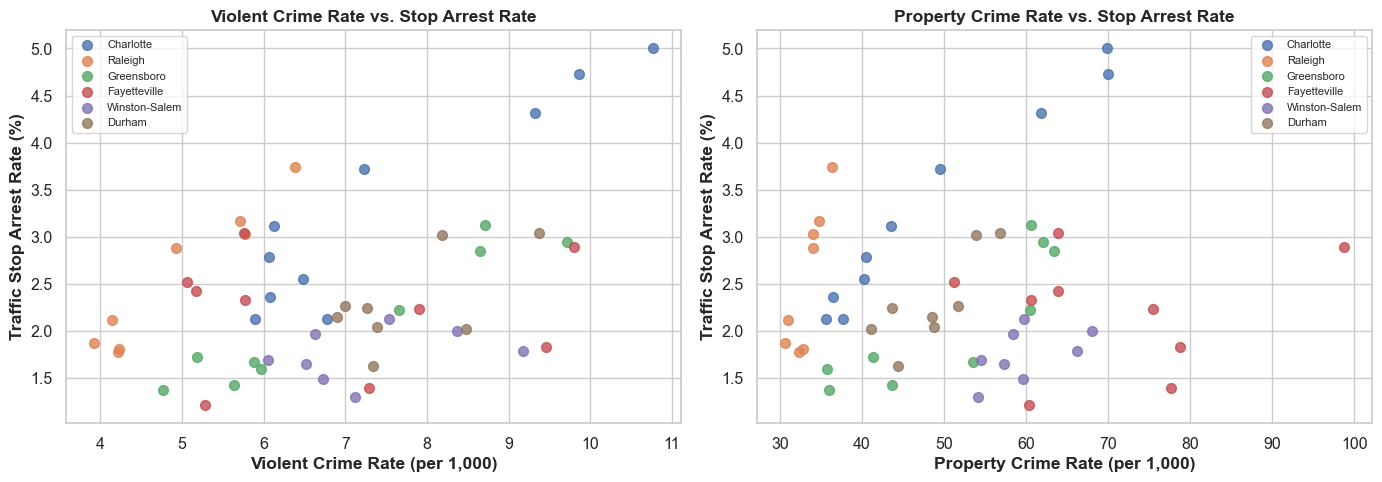

In [7]:
# Merge FBI crime rates with traffic stop arrest rates by city-year
stops_by_cy = df.groupby(["city", "year"]).agg(
    n_stops=("arrested", "size"),
    n_arrests=("arrested", "sum"),
    arrest_rate=("arrested", "mean")
).reset_index()
stops_by_cy["arrest_rate"] *= 100

merged = stops_by_cy.merge(fbi[["City", "Year", "violent_crime_rate", "property_crime_rate"]],
                           left_on=["city", "year"], right_on=["City", "Year"], how="inner")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, crime_col, label in zip(axes,
    ["violent_crime_rate", "property_crime_rate"],
    ["Violent Crime Rate (per 1,000)", "Property Crime Rate (per 1,000)"]):
    for city in CITY_ORDER:
        sub = merged[merged["city"] == city]
        ax.scatter(sub[crime_col], sub["arrest_rate"], label=city, s=50, alpha=0.8)
    ax.set_xlabel(label, fontweight="bold")
    ax.set_ylabel("Traffic Stop Arrest Rate (%)", fontweight="bold")
    ax.legend(fontsize=8)
axes[0].set_title("Violent Crime Rate vs. Stop Arrest Rate", fontweight="bold")
axes[1].set_title("Property Crime Rate vs. Stop Arrest Rate", fontweight="bold")
plt.tight_layout()
plt.savefig("eda/04_crime_rate_vs_arrest_rate.png", dpi=150, bbox_inches="tight")
plt.show()

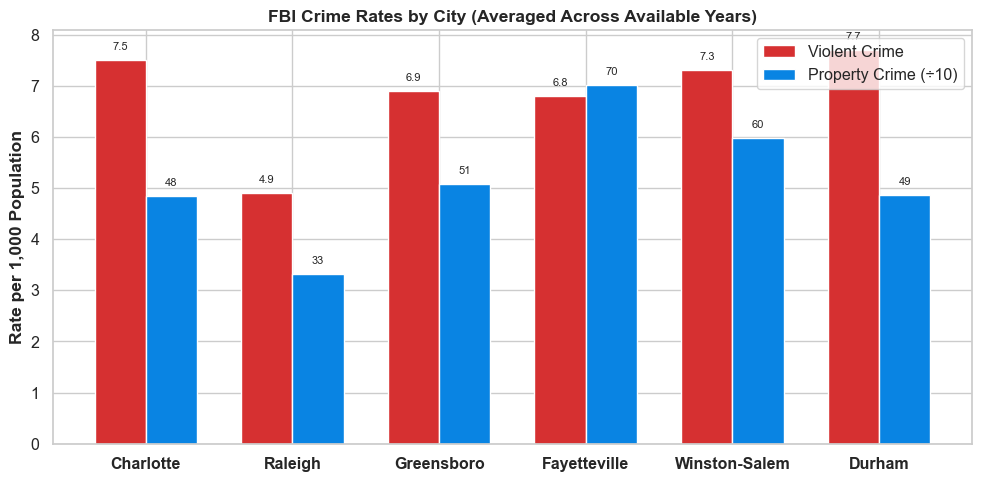

In [8]:
# FBI violent crime rate per capita by city (averaged across available years)
fbi_avg = fbi.groupby("City")[["violent_crime_rate", "property_crime_rate"]].mean().round(1)
fbi_avg = fbi_avg.reindex([c for c in CITY_ORDER if c in fbi_avg.index])

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(fbi_avg))
w = 0.35
ax.bar(x - w/2, fbi_avg["violent_crime_rate"], w, label="Violent Crime", color="#d63031")
ax.bar(x + w/2, fbi_avg["property_crime_rate"] / 10, w, label="Property Crime (÷10)", color="#0984e3")
ax.set_xticks(x)
ax.set_xticklabels(fbi_avg.index, fontweight="bold")
ax.set_ylabel("Rate per 1,000 Population", fontweight="bold")
ax.set_title("FBI Crime Rates by City (Averaged Across Available Years)", fontweight="bold")
ax.legend()
for i, (v, p) in enumerate(zip(fbi_avg["violent_crime_rate"], fbi_avg["property_crime_rate"])):
    ax.text(i - w/2, v + 0.2, f"{v:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, p/10 + 0.2, f"{p:.0f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("eda/05_fbi_crime_rates_by_city.png", dpi=150, bbox_inches="tight")
plt.show()